# Meta–Utah Joint Embedding

Meta and Utah use separate channel-specific stems but share a temporal representation and five-class classifier. Supervised contrastive learning treats same-gesture examples across domains as positives without requiring paired recordings.

The Utah validation split selects the checkpoint. The Utah test split is touched once afterward.

## 1. Configuration and semantic class mapping

In [1]:
from pathlib import Path
import copy, csv, json, math, pickle, random, sys
from collections import OrderedDict

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from scipy.signal import butter, resample_poly, sosfiltfilt
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

REPO_ROOT = Path(r"C:\Users\Micah\utah-neuro\generic_neuromotor_interface")
UTAH_DATA_PATH = REPO_ROOT / "New_Gesture_Trial_Dataset_Labeled (2).pt"
META_SOURCE_DIR = REPO_ROOT / "emg_data"
EXPERIMENT_ROOT = Path(r"C:\Users\Micah\utah-neuro\MATLAB_Jupyter\04_representation_learning")

CLASS_NAMES = ["thumb left", "thumb right", "thumb up", "thumb down", "thumb press"]
# Official repository order: click=4, down=5, in=6, out=7, up=8.
# Assumption for a right hand: Utah left=in and Utah right=out. Reverse the first
# two entries if the Utah task used the opposite hand/orientation.
UTAH_TO_META_IDS = [6, 7, 8, 5, 4]
META_NAMES_BY_UTAH_CLASS = ["thumb_in", "thumb_out", "thumb_up", "thumb_down", "thumb_click"]
META_NAME_TO_CLASS = {name: i for i, name in enumerate(META_NAMES_BY_UTAH_CLASS)}

UTAH_HZ, META_HZ = 30_000, 2_000
UTAH_CHANNELS, META_CHANNELS, WINDOW_SAMPLES = 32, 16, 2_000
BATCH_SIZE = 16
META_BATCH_SIZE = 64
NUM_WORKERS = 0  # HDF5-safe in Jupyter/Windows
EMBED_DIM = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 120
PATIENCE = 25
META_MAX_FILES = None       # None uses all available Meta user files
META_EVENTS_PER_CLASS_PER_FILE = 12
HIGH_PASS_HZ = 40.0

assert UTAH_DATA_PATH.exists(), UTAH_DATA_PATH
assert META_SOURCE_DIR.exists(), META_SOURCE_DIR
assert len(set(UTAH_TO_META_IDS)) == 5
print("Device:", DEVICE)
print("Utah data:", UTAH_DATA_PATH)
print("Meta source:", META_SOURCE_DIR)
print("Semantic mapping:", dict(zip(CLASS_NAMES, META_NAMES_BY_UTAH_CLASS)))


Device: cpu
Utah data: C:\Users\Micah\utah-neuro\generic_neuromotor_interface\New_Gesture_Trial_Dataset_Labeled (2).pt
Meta source: C:\Users\Micah\utah-neuro\generic_neuromotor_interface\emg_data
Semantic mapping: {'thumb left': 'thumb_in', 'thumb right': 'thumb_out', 'thumb up': 'thumb_up', 'thumb down': 'thumb_down', 'thumb press': 'thumb_click'}


## 2. Utah trial windows and labelled Meta event windows

In [2]:
UTAH_HP = butter(4, HIGH_PASS_HZ, btype="highpass", fs=META_HZ, output="sos")

def crop_or_pad_time(x, start, length):
    out = torch.zeros((length,) + tuple(x.shape[1:]), dtype=x.dtype)
    src0, src1 = max(0, start), min(len(x), start + length)
    if src1 > src0:
        out[src0 - start:src1 - start] = x[src0:src1]
    return out

def prepare_utah_trial(trial):
    emg = torch.as_tensor(trial["ns5_vector"]).float()
    if emg.ndim != 2: raise ValueError(f"Bad Utah EMG shape {tuple(emg.shape)}")
    if emg.shape[0] == UTAH_CHANNELS: emg = emg.T
    if emg.shape[1] != UTAH_CHANNELS: raise ValueError(tuple(emg.shape))
    labels = torch.as_tensor(trial["trainKin"]).float()
    if labels.shape[0] != emg.shape[0]: labels = labels.T
    valid = torch.as_tensor(trial.get("valid_mask", torch.ones(len(emg)))).bool().flatten()
    active = (labels[:, :5].amax(1) > .5) & valid[:len(labels)]
    idx = torch.nonzero(active, as_tuple=False).flatten()
    if len(idx) == 0: raise ValueError(f"Trial {trial.get('trial_num')} has no active label")
    center = int(torch.round(idx.float().mean()).item())
    raw = crop_or_pad_time(emg, center - UTAH_HZ // 2, UTAH_HZ).T.numpy()
    x = resample_poly(raw, up=1, down=UTAH_HZ // META_HZ, axis=1)
    x = sosfiltfilt(UTAH_HP, x, axis=1).astype(np.float32)
    if x.shape != (UTAH_CHANNELS, WINDOW_SAMPLES): raise RuntimeError(x.shape)
    scale = np.median(np.abs(x), axis=1, keepdims=True) + 1e-6
    x = np.clip(x / scale, -20, 20).astype(np.float32)
    return torch.from_numpy(x), int(trial["gesture"]), int(trial["trial_num"])

class UtahTrials(Dataset):
    def __init__(self, trials):
        good = []
        for t in trials:
            try: good.append(prepare_utah_trial(t))
            except Exception as e: print("Skipping unusable Utah trial", t.get("trial_num"), e)
        self.items = good
    def __len__(self): return len(self.items)
    def __getitem__(self, i): return self.items[i]

def read_pandas_fixed_string_column(group, item_name="name"):
    items = [x.decode() for x in group["block0_items"][()]]
    j = items.index(item_name)
    payload = bytes(group["block0_values"][j])
    return np.asarray(pickle.loads(payload)).reshape(-1).astype(str)

class MetaGestureEvents(Dataset):
    """Labelled one-second event windows, indexed without PyTables."""
    def __init__(self, source_dir, max_files=None, per_class_per_file=12):
        files = sorted(Path(source_dir).glob("*.hdf5"))
        if max_files is not None: files = files[:max_files]
        self.files, self.events = files, []
        rng = np.random.default_rng(SEED)
        for file_i, path in enumerate(files):
            with h5py.File(path, "r") as f:
                names = read_pandas_fixed_string_column(f["prompts"], "name")
                times = np.asarray(f["prompts/block1_values"][:, 0])
                timestamps = f["data"]["time"]
                for name, cls in META_NAME_TO_CLASS.items():
                    candidates = np.flatnonzero(names == name)
                    if len(candidates) > per_class_per_file:
                        candidates = rng.choice(candidates, per_class_per_file, replace=False)
                    for j in candidates:
                        center = int(np.searchsorted(timestamps, times[j]))
                        self.events.append((file_i, center, cls))
        if not self.events: raise RuntimeError("No mapped Meta gesture events found")
        self._handles = OrderedDict()
    def __len__(self): return len(self.events)
    def _handle(self, file_i):
        if file_i not in self._handles:
            self._handles[file_i] = h5py.File(self.files[file_i], "r")
            if len(self._handles) > 16:
                _, old = self._handles.popitem(last=False); old.close()
        return self._handles[file_i]
    def __getitem__(self, i):
        file_i, center, cls = self.events[i]
        d = self._handle(file_i)["data"]
        start, end = center - WINDOW_SAMPLES // 2, center + WINDOW_SAMPLES // 2
        src0, src1 = max(0, start), min(len(d), end)
        x = np.zeros((META_CHANNELS, WINDOW_SAMPLES), np.float32)
        if src1 > src0: x[:, src0-start:src1-start] = np.asarray(d[src0:src1]["emg"], np.float32).T
        scale = np.median(np.abs(x), axis=1, keepdims=True) + 1e-6
        x = np.clip(x / scale, -20, 20).astype(np.float32)
        return torch.from_numpy(x), int(cls)

saved = torch.load(UTAH_DATA_PATH, map_location="cpu", weights_only=False)
utah_train, utah_val, utah_test = [UtahTrials(saved[k]) for k in ("train", "val", "test")]
meta_events = MetaGestureEvents(META_SOURCE_DIR, META_MAX_FILES, META_EVENTS_PER_CLASS_PER_FILE)

def loader(ds, batch, shuffle):
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

utah_train_loader = loader(utah_train, BATCH_SIZE, True)
utah_val_loader = loader(utah_val, BATCH_SIZE, False)
utah_test_loader = loader(utah_test, BATCH_SIZE, False)
meta_loader = loader(meta_events, META_BATCH_SIZE, True)
print("Utah train/val/test:", len(utah_train), len(utah_val), len(utah_test))
print("Meta files/events:", len(meta_events.files), len(meta_events))
print("Utah batch:", next(iter(utah_train_loader))[0].shape)
print("Meta batch:", next(iter(meta_loader))[0].shape)


Utah train/val/test: 80 10 10
Meta files/events: 100 6000
Utah batch: torch.Size([16, 32, 2000])


Meta batch: torch.Size([64, 16, 2000])


## 3. Matched-capacity temporal encoders and evaluation helpers

In [3]:
class ConvStem(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 48, 9, stride=4, padding=4, bias=False), nn.GroupNorm(6,48), nn.SiLU(),
            nn.Conv1d(48, 64, 7, stride=4, padding=3, bias=False), nn.GroupNorm(8,64), nn.SiLU(),
            nn.Conv1d(64, 96, 5, stride=2, padding=2, bias=False), nn.GroupNorm(8,96), nn.SiLU())
    def forward(self, x): return self.net(x)

class SharedTrunk(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(96, 128, 5, stride=2, padding=2, bias=False), nn.GroupNorm(8,128), nn.SiLU(),
            nn.Conv1d(128, 128, 3, padding=1, bias=False), nn.GroupNorm(8,128), nn.SiLU(),
            nn.AdaptiveAvgPool1d(1))
        self.proj = nn.Linear(128, embed_dim)
    def forward(self, x): return F.normalize(self.proj(self.net(x).squeeze(-1)), dim=1)

class SingleDomainClassifier(nn.Module):
    def __init__(self, channels):
        super().__init__(); self.stem=ConvStem(channels); self.trunk=SharedTrunk(); self.head=nn.Linear(EMBED_DIM,5)
    def forward(self,x,return_embedding=False):
        z=self.trunk(self.stem(x)); logits=self.head(z)
        return (logits,z) if return_embedding else logits

def evaluate(model, data_loader, domain=None):
    model.eval(); ys=[]; ps=[]; loss_sum=0.; n=0
    with torch.no_grad():
        for batch in data_loader:
            x,y=batch[0].to(DEVICE),batch[1].to(DEVICE)
            logits=model(x,domain) if domain is not None else model(x)
            loss_sum += F.cross_entropy(logits,y,reduction="sum").item(); n += len(y)
            ys.extend(y.cpu().tolist()); ps.extend(logits.argmax(1).cpu().tolist())
    recalls=[]
    for c in range(5):
        idx=np.array(ys)==c
        if idx.any(): recalls.append(float((np.array(ps)[idx]==c).mean()))
    return {"loss":loss_sum/max(1,n),"acc":float(np.mean(np.array(ys)==np.array(ps))),
            "balanced_acc":float(np.mean(recalls)),"y":ys,"pred":ps}

def save_outputs(out_dir, model, history, result, extra):
    out_dir.mkdir(parents=True,exist_ok=True)
    torch.save({"model_state_dict":model.state_dict(),"class_names":CLASS_NAMES,
                "semantic_mapping":META_NAMES_BY_UTAH_CLASS,"extra":extra},out_dir/"best_model.pt")
    with open(out_dir/"history.json","w") as f: json.dump(history,f,indent=2)
    summary={k:v for k,v in result.items() if k not in ("y","pred")}; summary.update(extra)
    with open(out_dir/"test_metrics.json","w") as f: json.dump(summary,f,indent=2)
    cm=np.zeros((5,5),dtype=int)
    for y,p in zip(result["y"],result["pred"]): cm[y,p]+=1
    np.savetxt(out_dir/"test_confusion_matrix.csv",cm,fmt="%d",delimiter=",")
    fig,axs=plt.subplots(1,3,figsize=(16,4.5))
    axs[0].plot(history["train_loss"],label="train"); axs[0].plot(history["val_loss"],label="val"); axs[0].set(title="Loss",xlabel="epoch"); axs[0].legend()
    axs[1].plot(history["train_acc"],label="train"); axs[1].plot(history["val_acc"],label="val"); axs[1].axhline(.2,ls="--",c="k",alpha=.5); axs[1].set(title="Utah accuracy",xlabel="epoch",ylim=(0,1.05)); axs[1].legend()
    image=axs[2].imshow(cm,cmap="Blues"); axs[2].set_xticks(range(5),["left","right","up","down","press"],rotation=30,ha="right"); axs[2].set_yticks(range(5),["left","right","up","down","press"])
    axs[2].set(xlabel="Predicted",ylabel="True",title="Blind Utah test")
    threshold=cm.max()/2 if cm.size else 0
    for i in range(5):
        for j in range(5): axs[2].text(j,i,str(cm[i,j]),ha="center",va="center",color="white" if cm[i,j]>threshold else "black")
    fig.tight_layout(); fig.savefig(out_dir/"training_and_test.png",dpi=200); fig.savefig(out_dir/"training_and_test.svg")
    plt.show(); print(json.dumps(summary,indent=2)); print("Saved:",out_dir)


## 4. Train, validation-select, freeze, and evaluate

Epoch 001/120 | loss 4.3327 | Utah train 0.188 | Utah val 0.200 | val bal 0.200


Epoch 002/120 | loss 4.3158 | Utah train 0.100 | Utah val 0.200 | val bal 0.200


Epoch 003/120 | loss 4.3042 | Utah train 0.212 | Utah val 0.200 | val bal 0.200


Epoch 004/120 | loss 4.3034 | Utah train 0.212 | Utah val 0.300 | val bal 0.300


Epoch 005/120 | loss 4.2776 | Utah train 0.400 | Utah val 0.500 | val bal 0.500


...

Epoch 035/120 | loss 2.9131 | Utah train 1.000 | Utah val 0.800 | val bal 0.800


Epoch 036/120 | loss 2.8476 | Utah train 1.000 | Utah val 0.800 | val bal 0.800


Epoch 037/120 | loss 2.9103 | Utah train 1.000 | Utah val 0.600 | val bal 0.600


Epoch 038/120 | loss 2.9815 | Utah train 1.000 | Utah val 0.600 | val bal 0.600


Epoch 039/120 | loss 2.8319 | Utah train 1.000 | Utah val 0.800 | val bal 0.800
Early stopping


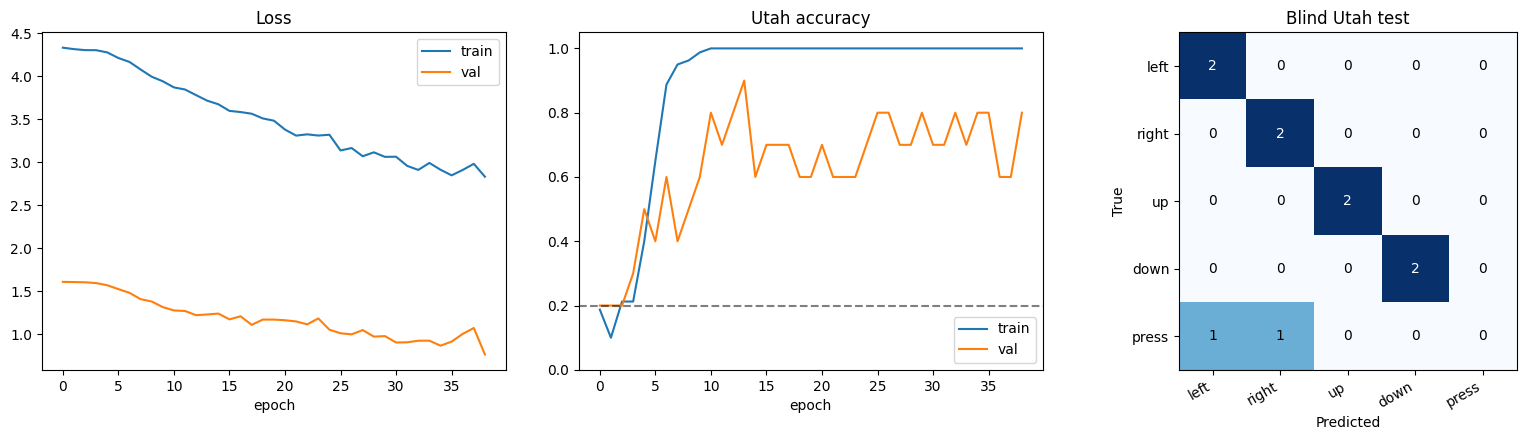

{
  "loss": 1.2527382850646973,
  "acc": 0.8,
  "balanced_acc": 0.8,
  "method": "two-stem joint supervised contrastive embedding",
  "best_epoch": 14,
  "supcon_weight": 0.25,
  "temperature": 0.12
}
Saved: C:\Users\Micah\utah-neuro\MATLAB_Jupyter\04_representation_learning\joint_embedding


In [4]:
OUT_DIR = EXPERIMENT_ROOT / "results" / "joint_embedding"
SUPCON_WEIGHT = 0.25
TEMPERATURE = 0.12

class JointEmbeddingModel(nn.Module):
    def __init__(self):
        super().__init__(); self.meta_stem=ConvStem(META_CHANNELS); self.utah_stem=ConvStem(UTAH_CHANNELS); self.trunk=SharedTrunk(); self.head=nn.Linear(EMBED_DIM,5)
    def embed(self,x,domain):
        stem=self.meta_stem if domain=="meta" else self.utah_stem
        return self.trunk(stem(x))
    def forward(self,x,domain,return_embedding=False):
        z=self.embed(x,domain); logits=self.head(z); return (logits,z) if return_embedding else logits

def supervised_contrastive(z,y):
    sim=z@z.T/TEMPERATURE; sim=sim-sim.max(1,keepdim=True).values.detach()
    eye=torch.eye(len(y),dtype=torch.bool,device=y.device); positives=(y[:,None]==y[None,:])&~eye
    exp=torch.exp(sim)*~eye; log_prob=sim-torch.log(exp.sum(1,keepdim=True).clamp_min(1e-12))
    valid=positives.sum(1)>0
    return -(log_prob*positives).sum(1)[valid].div(positives.sum(1)[valid]).mean()

model=JointEmbeddingModel().to(DEVICE)
opt=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
history={k:[] for k in ("train_loss","val_loss","train_acc","val_acc","meta_ce","utah_ce","supcon")}
best_state=None; best_epoch=0; best_score=(-1,float("inf")); stale=0
for epoch in range(1,EPOCHS+1):
    model.train(); source_iter=iter(meta_loader); sums=np.zeros(4); correct=count=0
    for ux,uy,_ in utah_train_loader:
        try: mx,my=next(source_iter)
        except StopIteration: source_iter=iter(meta_loader); mx,my=next(source_iter)
        ux,uy,mx,my=ux.to(DEVICE),uy.to(DEVICE),mx.to(DEVICE),my.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        ulog,uz=model(ux,"utah",True); mlog,mz=model(mx,"meta",True)
        uce=F.cross_entropy(ulog,uy); mce=F.cross_entropy(mlog,my)
        con=supervised_contrastive(torch.cat([uz,mz]),torch.cat([uy,my]))
        loss=uce+mce+SUPCON_WEIGHT*con; loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),5.); opt.step()
        sums += [loss.item()*len(uy),uce.item()*len(uy),mce.item()*len(uy),con.item()*len(uy)]
        correct+=(ulog.argmax(1)==uy).sum().item(); count+=len(uy)
    val=evaluate(model,utah_val_loader,"utah")
    history["train_loss"].append(sums[0]/count); history["val_loss"].append(val["loss"]); history["train_acc"].append(correct/count); history["val_acc"].append(val["acc"])
    history["utah_ce"].append(sums[1]/count); history["meta_ce"].append(sums[2]/count); history["supcon"].append(sums[3]/count)
    score=(val["balanced_acc"],-val["loss"])
    if score>best_score: best_score=score; best_state=copy.deepcopy(model.state_dict()); best_epoch=epoch; stale=0
    else: stale+=1
    print(f"Epoch {epoch:03d}/{EPOCHS} | loss {sums[0]/count:.4f} | Utah train {correct/count:.3f} | Utah val {val['acc']:.3f} | val bal {val['balanced_acc']:.3f}")
    if stale>=PATIENCE: print("Early stopping"); break
model.load_state_dict(best_state)
test=evaluate(model,utah_test_loader,"utah")
save_outputs(OUT_DIR,model,history,test,{"method":"two-stem joint supervised contrastive embedding","best_epoch":best_epoch,"supcon_weight":SUPCON_WEIGHT,"temperature":TEMPERATURE})
